# Lecture 5: Supervised learning with CNNs

Link to Google Colab Notebook: https://colab.research.google.com/drive/1woNWZpeL_ajji-1oE5EuoNWd1ksBwyf4?usp=sharing

Based on the template code, I've loaded in the MagnaTagATune dataset and trained 2 models (CNN and MLP) to perform multi-label classificiation. This required changes such as:

- Using `MultiLableBinarizer` to encode the labels
- Using `Binary Cross-Entropy Loss` when evaluating loss
- Changing the SoftMax function to `Sigmoid` in order to hone in on stronger activations and reduce entropy in the output of the neural network
- Changing the accuracy metric to be calculated as Receiver Operating Characteristic Area Under the Curve (ROC AUC) which explains how well the model performs under all thresholds, evaluating for both the presence of false positives and false negatives


Task 1: Run both examples and discuss the performance difference.

The CNN performed better than the MLP when evaluated on the test dataset, suggesting that its convolutional layers capture local time-frequency features more effectively for genre classification, but performance could be improved upon in future iterations when looking at different depths and widths of the model.

Throughout the notebook, I will describe the changes made and the thought process behind it.

#### Steps:
1. Preprocess the dataset
2. Loading the Dataset
3. Feature Extraction
4. Define the MLP model
5. Define the CNN model
6. Train the model
7. Evaluate the model

In [5]:
# !pip install torch
# !pip install mirdata
# !pip install tqdm
# !pip install scikit-learn
# !pip install torchaudio
# !pip install matplotlib

In [6]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# import mirdata                            ### no longer needed

# AP - newly added imports
import os
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
import torchaudio.functional as ta_F

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer ## Added multilabelbinarizer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix ## added roc_auc_score, classification_report, and confusion_matrix
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, FrequencyMasking, TimeMasking, Vol ## added FrequencyMasking, TimeMasking, and Vol
from tqdm import tqdm

# AP - newly added imports
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:
# if torch.backends.mps.is_available():
#     device = torch.device("cpu")
# else:
#     device = torch.device("cpu")

#print("Using device:", device)

### Step 1: Preprocess the dataset

I downloaded the MagnaTagATune mp3 folder from [this website](https://huggingface.co/datasets/confit/magnatagatune/tree/main) and unzipped the folder manually, loading them into my google drive to be sourced into this project as our samples. I noticed some of the files were corrupt, so I removed these files from the dataset along with their labels.

To load labels, I downloaded the `annotations_final.csv` file from the [MagnaTagATune website](https://mirg.city.ac.uk/codeapps/the-magnatagatune-dataset). After visually looking through this file, I noticed some of the tags were more related to the instruments being used in the song rather than the genre itself, so I decided to only scope in columns which were named after genres (genres were defined by a list found in `song_info.csv` from the [Magratune API](https://magnatune.com/info/api)).

#### Data Split

In preparation for splitting, I wanted to consider the distribution of labels across the training and validation datasets to evaluate any prexisting biases in the dataset that may skew performance results. 

From the visualizations below, I can tell that certain labels are much more prevelant than others across the whole dataset such as "guitar", or "classical" with 4851 and 4270 occurences across the whole dataset respectively, whereas labels such as "world" and "reggae" had a much smaller presence (65 and 52 occurences respectively). This goes to show there is a genre bias within the dataset and maybe is not the best suited dataset for this specific task. 

Nevertheless, each of the track folders have a good representation of each of the genres, so I felt this was a better way to split the data rather than pure random splits which could result in inproportional splits. 


In [ ]:
# ==========================================================
# Load MagnaTagATune Annotations and Remove Corrupt Files
# ==========================================================

data_root = '/content/drive/MyDrive/'
mp3_root = '/content/drive/MyDrive/mp3'


annotations = pd.read_csv(os.path.join(data_root, 'annotations_final.csv'), delimiter='\t')

# Identify empty MP3 files
empty_files = [
    file for file in annotations.mp3_path.values
    if file.lower().endswith('.mp3')
    and os.path.exists(os.path.join(mp3_root, file))
    and os.path.getsize(os.path.join(mp3_root, file)) == 0
]

print(f"Empty_files:\n{empty_files}")
print(len(annotations))

# Drop empty/corrupt files from the list of annotations
annotations = annotations[~annotations['mp3_path'].isin(empty_files)].reset_index(drop=True)

# Saving this version of annotations prior to genre filtering
all_annotations = annotations

print(len(annotations))

Empty_files:
['6/norine_braun-now_and_zen-08-gently-117-146.mp3', '8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3', '9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3']
25863
25860


In [63]:
# ==========================================================
# Filter Annotations for Only Relevant Genre Info
# ==========================================================

song_info = pd.read_csv(os.path.join(data_root, 'song_info.csv'), on_bad_lines='skip').fillna('')

# Splitting and cleaning genre information
def split_genres(col):
    genres = [g.strip().lower() for i in song_info[col].values for g in i.split(',') if g.strip()]
    return list(set(genres))

mp3_genre = split_genres('mp3genre')
magnatunegenres = split_genres('magnatunegenres')

# Aggregate a "complete" list of genres from both columns into a final list of all genres
all_genres =list(set(mp3_genre + magnatunegenres))

# Match the column names in Annotations_File.csv with the list of genres we've compiled above
annotations_labels = annotations.columns.values
genre_columns = [i for i in annotations_labels if i in all_genres]

# List of columns we will want to pull from the annotations_file.csv file
selected_columns = ['clip_id'] + genre_columns + ['mp3_path']
annotations = annotations[selected_columns]

# Remove rows that do not have any genre labels
annotations = annotations[~(annotations[genre_columns].sum(axis=1) == 0)]

annotations['track_folder'] = [i[0] for i in annotations['mp3_path'].str.split('/')]

# Print the removed columns to visually confirm they are not genre related
kept_columns = selected_columns + ['track_folder']
removed_columns = [col for col in all_annotations if col not in kept_columns]
print(f"Total original columns: {len(all_annotations)}")
print(f"Columns kept: {len(kept_columns)}")
print(f"Columns removed: {len(removed_columns)}")
print(f"\nRemoved columns:\n{removed_columns}")

print("\nAnnotations Dataframe:")
annotations

Total original columns: 25860
Columns kept: 36
Columns removed: 155

Removed columns:
['no voice', 'singer', 'duet', 'plucking', 'bongos', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal', 'vocals', 'clarinet', 'heavy', 'silence', 'beats', 'men', 'woodwind', 'funky', 'no strings', 'chimes', 'foreign', 'no piano', 'horns', 'female', 'no voices', 'soft rock', 'eerie', 'spacey', 'quiet', 'no beat', 'banjo', 'electric', 'solo', 'violins', 'female voice', 'wind', 'happy', 'synth', 'no singing', 'middle eastern', 'trumpet', 'percussion', 'drum', 'airy', 'voice', 'repetitive', 'birds', 'space', 'strings', 'bass', 'harpsicord', 'male voice', 'girl', 'keyboard', 'acoustic', 'loud', 'classic', 'string', 'drums', 'electronic', 'not classical', 'chanting', 'no violin', 'not rock', 'no guitar', 'organ', 'no vocal', 'talking', 'weird', 'soprano', 'fast', 'acoustic guitar', 'electric guitar', 'male singer', 'man singing', 'classical guitar', 'violin', 'electro', 'tribal',

,clip_id,hard rock,world,harpsichord,classical,jazz,guitar,folk,ambient,new age,...,blues,vocal,indian,rock,techno,metal,hip hop,baroque,mp3_path,track_folder
0,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...,f
1,6,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,f/american_bach_soloists-j_s__bach_solo_cantat...,f
2,10,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...,f
3,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...,f
4,12,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25855,58899,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,8/jacob_heringman-blame_not_my_lute-56-la_bres...,8
25856,58906,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,8/jacob_heringman-blame_not_my_lute-57-lost_is...,8
25857,58907,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,8/jacob_heringman-blame_not_my_lute-57-lost_is...,8
25858,58908,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,8/jacob_heringman-blame_not_my_lute-57-lost_is...,8


In [64]:
folder_label_distribution = annotations.groupby('track_folder')[genre_columns].sum()
print("Count of Labels in each Track Folder:")
folder_label_distribution

Count of Labels in each Track Folder:


,hard rock,world,harpsichord,classical,jazz,guitar,folk,ambient,new age,funk,...,punk,spanish,blues,vocal,indian,rock,techno,metal,hip hop,baroque
track_folder,,,,,,,,,,,,,,,,,,,,,
0,4,4,40,231,11,180,9,81,28,7,...,4,6,27,95,65,121,88,10,2,10
1,15,4,123,277,16,355,9,97,31,1,...,7,26,3,51,165,102,116,44,0,24
2,2,8,101,263,51,160,17,124,37,14,...,0,2,11,78,91,73,211,6,5,31
3,15,8,47,231,11,308,25,62,32,3,...,1,6,36,98,77,145,35,32,0,16
4,34,2,115,397,79,450,16,182,54,12,...,1,37,16,158,183,159,198,59,20,31
5,13,4,32,212,43,243,14,166,48,10,...,3,17,2,81,97,119,308,20,5,13
6,4,1,41,397,60,443,32,42,14,7,...,8,25,17,123,62,166,172,7,8,16
7,13,6,4,94,3,179,22,165,62,0,...,3,5,26,86,78,120,133,11,1,3
8,18,3,16,101,6,281,9,83,43,4,...,2,11,0,99,69,111,118,33,3,3


In [59]:
total_labels = annotations[genre_columns].sum()
print("Labels Sorted by Prevelance")
total_labels.sort_values(ascending=0)

Labels Sorted by Prevelance


guitar          4851
classical       4270
techno          2954
rock            2371
piano           2056
ambient         1956
vocal           1729
indian          1395
opera           1296
harpsichord     1092
pop              995
new age          650
country          541
metal            505
choral           490
jazz             439
instrumental     384
baroque          296
hard rock        274
folk             243
spanish          217
electronica      197
medieval         188
blues            181
irish            181
lute             123
punk             108
funk              95
industrial        73
world             65
hip hop           64
orchestral        56
reggae            52
dtype: int64

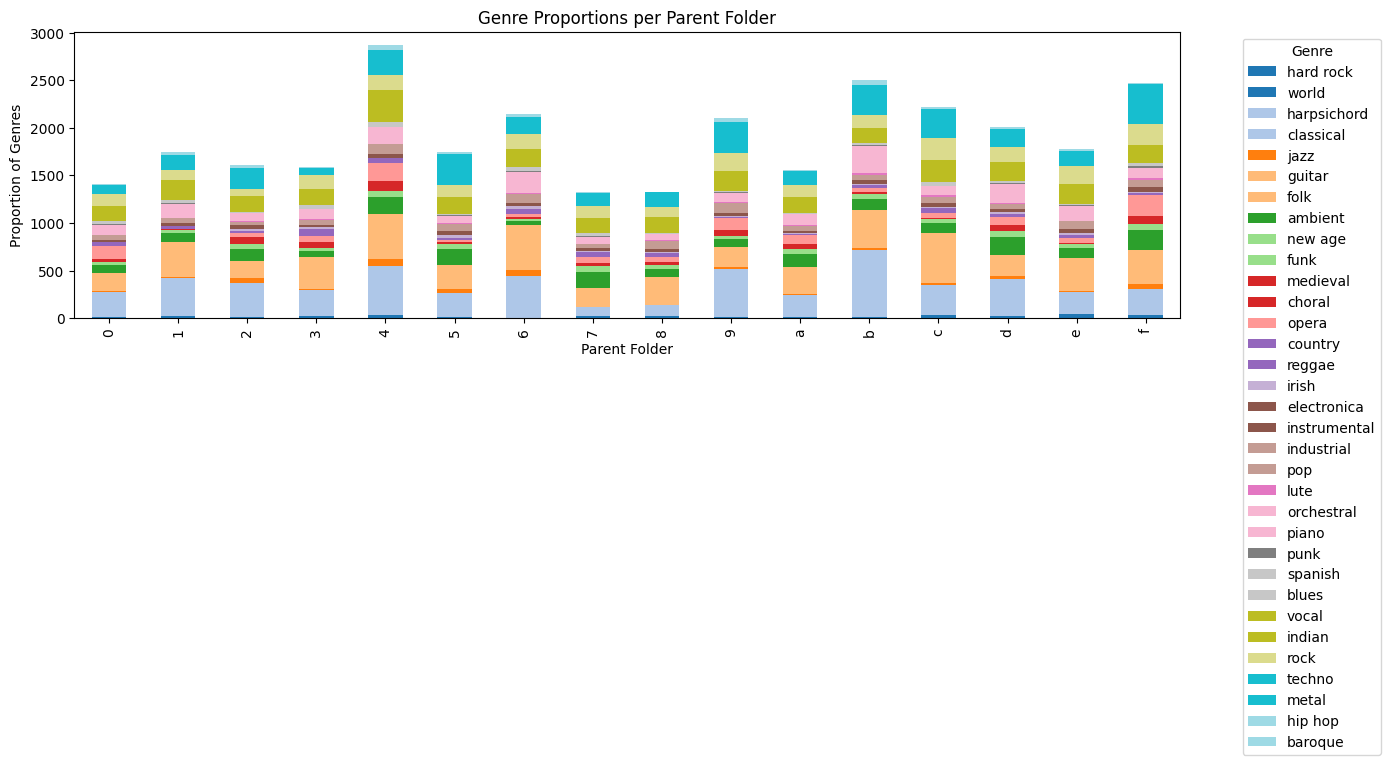

In [50]:
# Plot stacked bar chart
folder_label_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='tab20'
)

plt.title("Genre Proportions per Parent Folder")
plt.xlabel("Parent Folder")
plt.ylabel("Proportion of Genres")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [65]:
# ==========================================================
# Splitting Dataset Between Training / Validation / Testing
# ==========================================================

trainning_folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b' ]
val_folders = ['c']
test_folders = ['d','e','f']

train_split = annotations[annotations['track_folder'].isin(trainning_folders)]
val_split = annotations[annotations['track_folder'].isin(val_folders)]
test_split = annotations[annotations['track_folder'].isin(test_folders)]

In [14]:
# convert the train_split dataframe into a numpy array and pull only genre related columns (i.e. the labels)
y_train = train_split[train_split.columns[1:-2]].values
y_val = val_split[val_split.columns[1:-2]].values
y_test = test_split[test_split.columns[1:-2]].values

# convert the train_split dataframe into a numpy array and pull only metadata to identify the song (i.e. 'clip_id' and 'mp3_path')
X_train = train_split[[train_split.columns[0],train_split.columns[-2]]].values
X_val = val_split[[val_split.columns[0],val_split.columns[-2]]].values
X_test = test_split[[test_split.columns[0],test_split.columns[-2]]].values

print('X_train Shape:', X_train.shape)
print("y_train Shape:", y_train.shape)

X_train Shape: (13033, 2)
y_train Shape: (13033, 33)


### Step 2: Loading the dataset

In order to the load the dataset, I've established a `MagnaTagATune` class which loads and preprocesses the audio clips and their corresponding multi-lable genre annotations. This includes audio loading, resampling, cropping/padding to a fixed duration, and encodes the labels using `MultiLabelBinarizer`. The function returns each sample as a dictionary containing the waveform tensor and it's encoded genre labels. Some parameters in this class include:

- `sample_rate`: enables downsampling of the audio files to enhance computational efficiency. Currently, the function is set to a default value of 16k Hz meaning it will capture frequencies up to 8k Hz which is enough to capture the most perceptually relevant musical features.
- `transform`: allows for data augmentation methods to be employed during training to diversify the dataset and inhibit the model from overfitting
-`mlb`: allows for a specific use of `MultiLabelBinarizer`; helpful loading in the validation dataset and making sure the encoding of these labels corresponds to the training set 


Additionally, this class implements a function `_crop_or_pad` which is used to set all audio waveforms to a standardized number of samples based on `target_duration`, ensuring consistent input size for feature extraction, and also reducing the size of the clip to produce more generalizable content.

#### **Data Augmentation**
To generate more diversity in the audio training dataset and enhance generalization, I implemented a couple data augmentations, each with their relative probability of being employed. Augmentations make each epoch of training more useful since the model will be looking at slightly different samples each time. These augmentations include:

- Volume Augmentation - randomly picks a gain factor between 0.8 to 1.2 to apply to the amplitude of the waveform
- Frequency Masking - removes data within a certain range of frequencies in the spectrogram
- Time Masking - removes data within a certain range of time in the spectrogram

Additional methods tried but with no value to overall performance:

- Random Volume adjustment, +/- 6 dB
- Random Pitch shift +/- 2 semi-tones
- Light Gaussian Noise
- Random Polarity Inversion

These transformations of the data are specifically selected make sense within the context of the task and to not distort the sound in a way that would skew the results of the model.


In [66]:
# ================================
# Establishing Data Loading Class
# ================================

class MagnaTagATune(Dataset):
    def __init__(self, file_paths_and_ids, labels, target_duration=3.0, sample_rate=16000, transform=None, root_dir='./', mlb=None):
        
        self.sample_rate = sample_rate # Standardized sample rate
        self.audio_duration = target_duration
        self.file_paths_and_ids = file_paths_and_ids # This contains the X_train/val/test ['clip_id', 'mp3_path'], ...]
        self.target_samples = max(int(target_duration * sample_rate), 1024)
        self.root_dir = root_dir
        self.transform = transform

        # Initialize MultiLabelBinarizer if not provided
        if mlb is None:
            self.mlb = MultiLabelBinarizer()
            encoded_labels = self.mlb.fit_transform(labels)
        else:
            self.mlb = mlb
            encoded_labels = self.mlb.transform(labels)

        self.encoded_labels = encoded_labels  # <-- store encoded labels
        
        self.labels = {}
        self.audio_files = {}

        # Debug: basic info
        print(f"\nInitializing MagnaTagATune dataset with {len(file_paths_and_ids)} files.")
        print(f"Sample rate: {self.sample_rate}, Target samples: {self.target_samples}")

        # match labels with clip id for easier debugging
        for idx, (clip_id, relative_path) in enumerate(file_paths_and_ids):
            if not relative_path.startswith('mp3/'):
                relative_path = os.path.join('mp3', relative_path)
            self.audio_files[idx] = os.path.join(root_dir, relative_path)
            self.labels[idx] = torch.tensor(encoded_labels[idx], dtype=torch.float32)  # <-- use encoded

    def __len__(self):
        return len(self.file_paths_and_ids)

    def _crop_or_pad(self, waveform):
        num_samples = waveform.shape[-1]
        if num_samples > self.target_samples:
            # Random crop during training, center crop for evaluation (though this dataset uses it for both)
            start = random.randint(0, num_samples - self.target_samples)
            waveform = waveform[:, start:start + self.target_samples]
        elif num_samples < self.target_samples:
            # Pad with zeros at the end
            pad_amount = self.target_samples - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
        return waveform

    def __getitem__(self, idx):
    
        path = self.audio_files[idx]

        # Debug print
        # print(f"\nLoading file {idx}: {path}")

        try:
            #audio, sr = self.decoder(path)
            audio, sr = torchaudio.load(path)

        except Exception as e:
            print(f"Failed to load {path}: {e}")
            # Return zero audio + zero lables to avoid breaking DataLoader
            audio = torch.zeros((1, self.target_samples))
            sr = self.sample_rate

        if sr != self.sample_rate:
            # If the original audio has a different sample rate, resample it
            audio = torchaudio.functional.resample(audio, sr, self.sample_rate)

        audio = self._crop_or_pad(audio)

        label = self.labels[idx]

        # Debug: print shape info
        # print(f"Loaded waveform shape: {audio.shape}, Label shape: {label.shape}")

        return {"audio": audio, "labels": label}


In [16]:
# ==================================
# Define Data Augmentation Function
# ==================================

def audio_augmentation(waveform, sample_rate=16000, apply_prob=0.5):
    """
    Apply random augmentations to waveform
    Args:
        waveform: tensor of shape (channels, samples)
        sample_rate: audio sample rate
        apply_prob: probability of applying each augmentation
    """
    # --- Volume Augmentation (works for waveform or spectrogram amplitude) ---
    if torch.rand(1).item() < apply_prob:
        gain = torch.empty(1).uniform_(0.8, 1.2).item()
        vol_transform = T.Vol(gain=gain, gain_type="amplitude")
        waveform = vol_transform(waveform)

    # --- If input is 2D (e.g., mel spectrogram), apply masking augmentations ---
    if waveform.dim() == 2 or (waveform.dim() == 3 and waveform.shape[0] == 1):
        if torch.rand(1).item() < apply_prob:
            freq_mask = T.FrequencyMasking(freq_mask_param=15)
            waveform = freq_mask(waveform)
        if torch.rand(1).item() < apply_prob:
            time_mask = T.TimeMasking(time_mask_param=35)
            waveform = time_mask(waveform)

    return waveform


In [ ]:
# ==================================
# OLD Data Augmentation Function
# ==================================

# def audio_augmentation(waveform, sample_rate=16000, apply_prob=0.5): 
#     """ 
#     Apply random augmentations to waveform 
#     Args: 
#         waveform: tensor of shape (channels, samples) 
#         sample_rate: audio sample rate 
#         apply_prob: probability of applying each augmentation 
#     """ 
#     # Random volume adjustment (±6 dB) 
#     if torch.rand(1).item() < apply_prob: 
#         gain_db = torch.FloatTensor(1).uniform_(-6, 6).item() 
#         waveform = ta_F.gain(waveform, gain_db) 
    
#     # Random pitch shift (±2 semitones) 
#     if torch.rand(1).item() < apply_prob: 
#         n_steps = torch.randint(-2, 3, (1,)).item() 
#         if n_steps != 0: 
#             waveform = ta_F.pitch_shift(waveform, sample_rate, n_steps) 
    
#     #Add light gaussian noise 
#     if torch.rand(1).item() < apply_prob: 
#         noise = torch.randn_like(waveform) * 0.005 
#         waveform = waveform + noise 
        
#     # Random polarity inversion (flip waveform) 
#     if torch.rand(1).item() < 0.3: waveform = -waveform 
    
#     return waveform

In [ ]:
# ==================================
# Implement Loading Data Functions
# ==================================

sample_rate=16000

train_transforms= lambda x: audio_augmentation(x, sample_rate=sample_rate, apply_prob=0.5)
val_transforms=None

# Instantiate the dataset using the corrected class
train_dataset = MagnaTagATune(X_train, y_train, target_duration=3.0, transform=train_transforms, root_dir='/content/drive/MyDrive/')
val_dataset = MagnaTagATune(X_val, y_val,target_duration=3.0, transform=val_transforms,root_dir='/content/drive/MyDrive/', mlb=train_dataset.mlb)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, pin_memory=False)



Initializing MagnaTagATune dataset with 13033 files.
Sample rate: 16000, Target samples: 48000

Initializing MagnaTagATune dataset with 1337 files.
Sample rate: 16000, Target samples: 48000


### Step 3: Feature Extraction

The `FeatureExtractor` class uses `torchaudio.transforms.MelSpectrogram` to convert audio signals into log-scaled mel-spectrograms. Log compression is applied to reduce dynamic range and improve training stability. Further below, I plot 3 example mel-spectrograms to confirm the correct feature extraction function is being employed.

I've left this function relatively unchanged from the template code, besides adding a control for an additional dimension added to the tensor related to the number of channels (1).

In [18]:
# ==================================
# Defining Feature Extraction Class
# ==================================

# Feature extractor. Using mel-spectrogram

class FeatureExtractor(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        self.melspectrogram = MelSpectrogram(**kwargs)

    def forward(self, x):
        if x.ndim == 3 and x.shape[1] == 1:  # (batch, 1, time)
            x = x.squeeze(1)                 # -> (batch, time)
        x = self.melspectrogram(x)
        x = torch.log10(1 + 1000 * x)  # log-compression
        return x

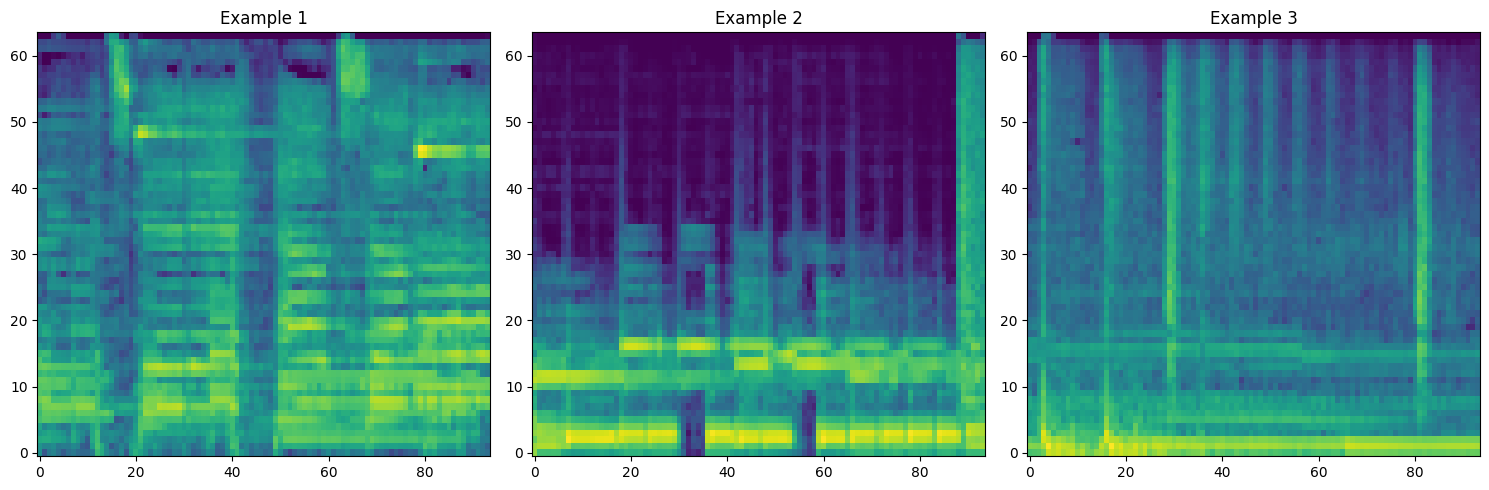

In [19]:
# ==================================
# Plotting Mel-Spectrogram Examples
# ==================================

feature_extractor = FeatureExtractor(n_mels=64, n_fft=1024)

# Fetch a batch of training data
batch = next(iter(train_loader))
mel_specs = feature_extractor(batch["audio"]).detach().numpy()

# Visualize the first three mel-spectrograms in the batch
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(mel_specs[i], aspect="auto", origin="lower")
    axes[i].set_title(f"Example {i+1}") # removed "{batch['natural_labels'][i]}" since we don't have this in our dataset "
plt.tight_layout()
plt.show()

In [20]:

n_classes = len(val_dataset.labels[0]) # changed natural_lables to labels

#batch = next(iter(val_loader))

mels = feature_extractor(batch["audio"])

print("Mel-spectrogram shape:", mels.shape)
print("Number of classes:", n_classes)


Mel-spectrogram shape: torch.Size([128, 64, 94])
Number of classes: 33


### Step 4: Define the MLP Model

The **Multi-Layer Perceptron (MLP)** defined here is a fully connected neural network that takes flattened mel-spectrogram features as input, passes them through two dense layers with ReLU activations, and outputs raw logits for each genre class. These logits can later be passed through a sigmoid function for multi-label classification.

This is relatively unchanged from the template code as well. I tried to make an archicture which included more normaization and dropout, but this inevitably did not help performance, likely since the input does not have dimensions of vastly different scales.

In [22]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size,
        dense_size: int=64,
        n_classes: int=188,
    ):
        super().__init__()
        self.fc1 = nn.Linear(input_size, dense_size)
        self.fc2 = nn.Linear(dense_size, dense_size)
        self.fc3 = nn.Linear(dense_size, n_classes)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)  # reduced dimensionality from .flatten(x, 1, 2)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
# ======================================
# Attempt to Alter the MLP Architecture
# ======================================

## MODIFIED MLP
# class MLP(nn.Module):
#     def __init__(
#         self,
#         input_size,
#         dense_size: int=64,
#         n_classes: int=188,
#         dropout_rate: float=0.3
#     ):
#         super().__init__()
#         self.fc1 = nn.Linear(input_size, dense_size)
#         self.bn1 = nn.BatchNorm1d(dense_size)
#         self.fc2 = nn.Linear(dense_size, dense_size)
#         self.bn2 = nn.BatchNorm1d(dense_size)
#         self.fc3 = nn.Linear(dense_size, n_classes)

#         # Regularization
#         self.dropout = nn.Dropout(dropout_rate)

#     def forward(self, x):
#         # Flatten input (batch, channels, freq, time)
#         x = torch.flatten(x, start_dim=1)  # reduced dimensionality from .flatten(x, 1, 2)

#         # First block
#         x = F.relu(self.bn1(self.fc1(x)))
#         x = self.dropout(x)

#         # Second block
#         x = F.relu(self.bn2(self.fc2(x)))
#         x = self.dropout(x)

#         # Output layer
#         x = self.fc3(x)

#         # Sigmoid for multi-lable output
#         x = torch.sigmoid(x)

#         return x


### Step 5: Define the CNN Model

The **Convolutional Neural Network (CNN)** defined here is designed to capture local time–frequency patterns in mel-spectrograms. It applies three 2D convolutional layers with ReLU activations and max-pooling to progressively reduce spatial dimensions while extracting hierarchical features. The resulting feature maps are flattened and passed through two fully connected layers to produce class-wise logits. A sigmoid activation can later be applied for multi-label genre classification.

This is relatively unchanged from the template code as well. I tried to implement batch normalization, ReLU and MaxPooling, but this also did not improve performance and therefore has been excluded from the final results.


In [24]:
class CNN(nn.Module):
    def __init__(
        self,
        kernel_size: int=3,
        pooling_size: int=4,
        dense_size: int=64,
        n_classes: int=188,
    ):
        super().__init__()
        self.dense_size = dense_size
        self.conv1 = nn.Conv2d(1, dense_size // 4, kernel_size=kernel_size, stride=1, padding=1)
        self.conv2 = nn.Conv2d(dense_size // 4, dense_size // 2, kernel_size=kernel_size, stride=1, padding=1)
        self.conv3 = nn.Conv2d(dense_size // 2, dense_size, kernel_size=kernel_size, stride=1, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=pooling_size, stride=pooling_size)
        self.fc1 = nn.Linear(dense_size, dense_size)
        self.fc2 = nn.Linear(dense_size, n_classes)  # Assuming 10 classes

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)
        # x = x.unsqueeze(1)  # Add channel dimension: (32, 64, 94) -> (32, 1, 64, 94)
        x = self.pool(F.relu(self.conv1(x)))  # -> (32, 16, 64, 94) -> (32, 16, 16, 23)
        x = self.pool(F.relu(self.conv2(x)))  # -> (32, 32, 16, 23) -> (32, 32, 4, 5)
        x = self.pool(F.relu(self.conv3(x)))  # -> (32, 64, 4, 5) -> (32, 64, 1, 1)

        x = x.view(-1, self.dense_size)   # -> (32, 64)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [23]:
# ==================================
# Defining the CNN Architecture
# ==================================

### MODIFIED CNN
# class CNN(nn.Module):
#     def __init__(self, n_classes):
#         super().__init__()
#         self.conv_layers = nn.Sequential(
#             nn.Conv2d(1, 32, kernel_size=(3,3), padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d((2,2)),

#             nn.Conv2d(32, 64, kernel_size=(3,3), padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d((2,2)),

#             nn.Conv2d(64, 128, kernel_size=(3,3), padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool2d((1, 1))
#         )

#         self.fc = nn.Sequential(
#             nn.Flatten(),
#             nn.Dropout(0.3),
#             nn.Linear(128, n_classes)
#         )

#     def forward(self, x):
#         if x.ndim == 3:
#             x = x.unsqueeze(1)
#         x = self.conv_layers(x)
#         x = self.fc(x)
#         return x

### Step 6: Train the models


The `train` function is built to take in the model, set a fixed number of epochs to train on, and a learning rate and output training loss, validation loss and ROC AUC values for each epoch.  

Here, I implement `BCEWithLogitsLoss()` as a more appropriate loss function for a multi-label task. Additionally, this training function implements `with.torch.no_grad` to avoid the vanishing gradient phenomenon.

Additionally, I've changed the output functions of the validation loop from evaluating the estimations based on softmax to sigmoid functions. This ensures we are honing in on the strongest activations from the models and reducing entropy in predictions.

Prior to training the models, I checked to see if GPU is available to train on and speed up the process. During training, I move both the model and the feature_extractor function to GPU if possible.





In [25]:
# ==================================
# Checking if GPU is available
# ==================================

# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available! PyTorch can use the GPU.")
    # Print the name of the GPU being used
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    # Print the number of GPUs available
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("CUDA is not available. PyTorch will use the CPU.")

CUDA is not available. PyTorch will use the CPU.


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Example: Move a tensor to the GPU
x = torch.randn(2, 3)
print(f"Tensor before moving to device: {x.device}")
x = x.to(device)
print(f"Tensor after moving to device: {x.device}")

Using device: cpu
Tensor before moving to device: cpu
Tensor after moving to device: cpu


In [30]:
save_path = 'Lab 5'

In [31]:
# ==================================
# Setting up Model Train Function
# ==================================

def train(model, n_epochs=3, lr=0.001):
    criterion = nn.BCEWithLogitsLoss()  # Multi-label
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model = model.to(device)
    feature_extractor = FeatureExtractor(n_mels=64, n_fft=1024).to(device)

    all_train_losses = []
    all_val_losses = []
    all_train_rocs = []
    all_val_rocs = []
    
    best_val_roc = -np.inf

    for epoch in range(n_epochs):

        # ---------- TRAIN ----------
        model.train()
        train_batch_losses = []
        all_y_true_train, all_y_pred_train = [], []
        
        train_pbar = tqdm(train_loader, desc=f'Epoch [{epoch + 1}/{n_epochs} Train]', leave=False)
        for batch in train_pbar:
            x = batch["audio"].to(device, non_blocking=True)
            y = batch["labels"].to(device, non_blocking=True)

            optimizer.zero_grad()
            x = feature_extractor(x)
            y_est = model(x)

            loss = criterion(y_est, y)
            loss.backward()
            optimizer.step()

            train_batch_losses.append(loss.item())
            y_pred = torch.sigmoid(y_est).detach().cpu().numpy()
            y_true = y.cpu().numpy()
            all_y_pred_train.append(y_pred)
            all_y_true_train.append(y_true)
            
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_train_loss = np.mean(train_batch_losses)
        all_train_losses.append(epoch_train_loss)
        
        all_y_true_train = np.concatenate(all_y_true_train, axis=0)
        all_y_pred_train = np.concatenate(all_y_pred_train, axis=0)

        # Compute training ROC-AUC
        roc_aucs_train = []
        for i in range(all_y_true_train.shape[1]):
            if len(np.unique(all_y_true_train[:,i]))>1:
                roc_aucs_train.append(roc_auc_score(all_y_true_train[:,i], all_y_pred_train[:,i]))
        epoch_train_roc = np.mean(roc_aucs_train) if len(roc_aucs_train) > 0 else float('nan')
        all_train_rocs.append(epoch_train_roc)
        
        # ---------- VALIDATION ----------
        model.eval()
        val_batch_losses = []
        all_y_true_val, all_y_pred_val = [], []
        
        val_pbar = tqdm(val_loader, desc=f'Epoch [{epoch+1}/{n_epochs}] [Val]', leave=False)
        with torch.no_grad():
            for batch in val_pbar:
                x = batch["audio"].to(device, non_blocking=True)
                y = batch["labels"].to(device, non_blocking=True)

                x = feature_extractor(x)
                y_est = model(x)

                loss = criterion(y_est, y)
                val_batch_losses.append(loss.item())

                # Collect predictions and labels for ROC AUC
                y_pred = torch.sigmoid(y_est).cpu().numpy()  # get probs for BCE
                y_true = y.cpu().numpy()
                all_y_true_val.append(y_true)
                all_y_pred_val.append(y_pred)

                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_val_loss = np.mean(val_batch_losses)
        all_val_losses.append(epoch_val_loss)
        
        all_y_true_val = np.concatenate(all_y_true_val, axis=0)
        all_y_pred_val = np.concatenate(all_y_pred_val, axis=0)

        # Compute ROC AUC per label, only for labels with both classes

        roc_aucs_val = []
        for i in range(all_y_true_val.shape[1]):
            if len(np.unique(all_y_true_val[:,i]))>1:
                roc_aucs_val.append(roc_auc_score(all_y_true_val[:,i], all_y_pred_val[:,i]))
        epoch_val_roc = np.mean(roc_aucs_val) if len(roc_aucs_val) > 0 else float('nan')
        all_val_rocs.append(epoch_val_roc)

        if epoch_val_roc > best_val_roc:
            best_val_roc = epoch_val_roc
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model (ROC-AUC: {best_val_roc:.4f})")        

        print(
            f"Epoch [{epoch + 1}/{n_epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Train ROC-AUC: {epoch_train_roc:.4f} | "
            f"Val ROC-AUC: {epoch_val_roc:.4f}"
        )
    print(f"\nTraining complete. Best Val ROC-AUC: {best_val_roc:.4f}")
    return all_train_losses, all_val_losses, all_train_rocs, all_val_rocs


In [32]:
# ==================================
# Calling Training Function
# ==================================

batch = next(iter(train_loader))
features = feature_extractor(batch["audio"])

mlp = MLP(mels.shape[1] * mels.shape[2], dense_size=32, n_classes=n_classes)
num_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP parameters: {num_params}")

# Get the input shape for CNN from feature extractor output
cnn = CNN( n_classes=n_classes)
num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"CNN Trainable parameters: {num_params}")

print("\nTraining MLP model")
mlp_all_train_losses, mlp_all_val_losses, mlp_all_train_rocs, mlp_all_val_rocs = train(mlp, n_epochs=10)

print("\nTraining CNN model")
cnn_all_train_losses, cnn_all_val_losses, cnn_all_train_rocs, cnn_all_val_rocs = train(cnn, n_epochs=10)

MLP parameters: 194689
CNN Trainable parameters: 29601

Training MLP model


Saved best model (ROC-AUC: 0.5945)
Epoch [1/10] Train Loss: 0.2582 | Val Loss: 0.1532 | Train ROC-AUC: 0.5062 | Val ROC-AUC: 0.5945


Saved best model (ROC-AUC: 0.6735)
Epoch [2/10] Train Loss: 0.1576 | Val Loss: 0.1443 | Train ROC-AUC: 0.6076 | Val ROC-AUC: 0.6735


Saved best model (ROC-AUC: 0.6804)
Epoch [3/10] Train Loss: 0.1512 | Val Loss: 0.1372 | Train ROC-AUC: 0.6562 | Val ROC-AUC: 0.6804


Saved best model (ROC-AUC: 0.7204)
Epoch [4/10] Train Loss: 0.1477 | Val Loss: 0.1345 | Train ROC-AUC: 0.6836 | Val ROC-AUC: 0.7204


...

Saved best model (ROC-AUC: 0.8125)
Epoch [6/10] Train Loss: 0.1272 | Val Loss: 0.1235 | Train ROC-AUC: 0.8114 | Val ROC-AUC: 0.8125


Saved best model (ROC-AUC: 0.8145)
Epoch [7/10] Train Loss: 0.1247 | Val Loss: 0.1155 | Train ROC-AUC: 0.8221 | Val ROC-AUC: 0.8145


Saved best model (ROC-AUC: 0.8224)
Epoch [8/10] Train Loss: 0.1227 | Val Loss: 0.1164 | Train ROC-AUC: 0.8317 | Val ROC-AUC: 0.8224


Saved best model (ROC-AUC: 0.8302)
Epoch [9/10] Train Loss: 0.1190 | Val Loss: 0.1123 | Train ROC-AUC: 0.8464 | Val ROC-AUC: 0.8302


Saved best model (ROC-AUC: 0.8405)
Epoch [10/10] Train Loss: 0.1180 | Val Loss: 0.1134 | Train ROC-AUC: 0.8469 | Val ROC-AUC: 0.8405

Training complete. Best Val ROC-AUC: 0.8405


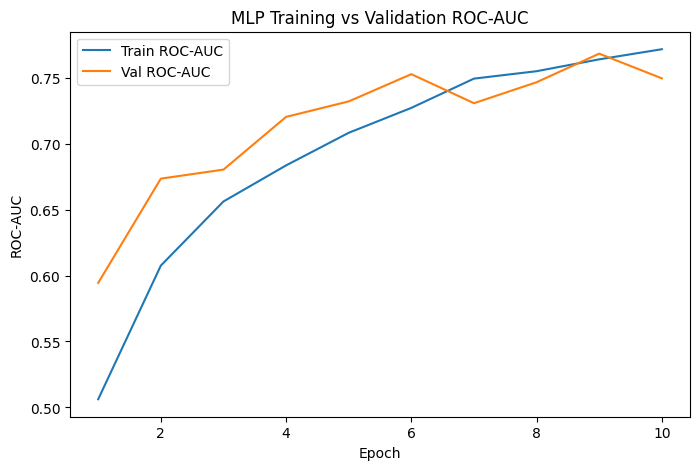

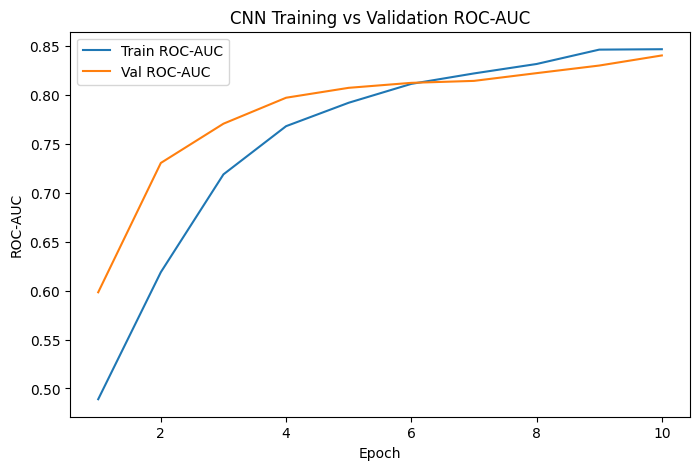

In [33]:
# ========================
# Plot results per Epoch
# ========================

# MLP Plot 

mlp_epochs = range(1, len(mlp_all_train_losses)+1)

plt.figure(figsize=(8,5))
plt.plot(mlp_epochs, mlp_all_train_rocs, label='Train ROC-AUC')
plt.plot(mlp_epochs, mlp_all_val_rocs, label='Val ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('MLP Training vs Validation ROC-AUC')
plt.legend()
plt.show()

# CNN Plot 

cnn_epochs = range(1, len(cnn_all_train_losses)+1)

plt.figure(figsize=(8,5))
plt.plot(cnn_epochs, cnn_all_train_rocs, label='Train ROC-AUC')
plt.plot(cnn_epochs, cnn_all_val_rocs, label='Val ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('CNN Training vs Validation ROC-AUC')
plt.legend()
plt.show()


### Step 7: Evaluate the Models

Using the testing dataset, I evaluated the performance of both the **Multi-Layer Perceptron (MLP)** as a baseline and the **Convolutional Neural Network (CNN)** on unseen audio samples. Because the dataset is highly imbalanced across genre labels, the **macro-averaged F1 and ROC AUC scores** are highlighted here to provide a more balanced view of performance across all genres, rather than favoring the most frequent ones.  

| Model   | Test Accuracy (Top-1) | F1 Score (Macro) |  ROC AUC (Macro)  |
| :------ | :-------------------: | :--------------: | :---------------: |
| **MLP** |   0.2640 |   0.1193  | 0.7779|
| **CNN** |   0.3786  |   0.1480  | 0.8523 |

#### Baseline MLP Performance 
The MLP serves as a conceptual baseline. It treats each spectrogram feature independently and does not explicitly leverage the spatial or local structure present in 2D mel-spectrograms. As expected:

- Top-1 accuracy and macro F1 are relatively low, indicating difficulty in generalizing across both common and rare genres.
- The model performs better on frequent or acoustically distinctive labels (e.g., harpsichord, rock), but struggles with overlapping or ambiguous classes (e.g., vocal, instrumental).
- Micro F1 and ROC AUC are higher than macro metrics, reflecting the influence of frequent labels on global performance.

#### CNN: Improvements over MLP Baseline

The CNN consistently outperforms the MLP across all metrics:

- **Accuracy**: The higher top-1 accuracy shows that convolutional layers capture local time–frequency dependencies, improving identification of the dominant genre per track.
- **F1 Score (Macro)**: An improved macro F1 suggests better balance across frequent and rare labels, indicating some generalization beyond majority classes.
- **ROC AUC (Macro)**: Stronger ROC AUC values reflect more reliable probabilistic discrimination, meaning the CNN ranks correct genres higher even without thresholding.

The CNN leverages spatially-aware feature extraction, allowing it to recognize harmonic, timbral, and rhythmic structures that the MLP cannot. This explains its consistent improvement, particularly for genres with distinctive acoustic signatures (e.g., techno, harpsichord, rock).

#### Label-Level Metrics 

Due to the heavily imbalanced nature of the dataset, it’s evident that the top-performing labels correspond closely to the most frequent ones (e.g., guitar, classical, techno, rock). This suggests that the supervised model has learned to favor majority classes, likely due to their overrepresentation during training. Consequently, the models achieve higher F1 and ROC-AUC scores for popular genres but struggle with underrepresented ones. 

Labels like rock, techno, and harpsichord consistently perform well, possibly because they have distinctive timbral or rhythmic characteristics that are easily learnable. Conversely, genres such as vocal, instrumental, and industrial show poor ROC-AUC scores, indicating class overlap or ambiguous labeling (these genres may share sonic similarities with multiple others), making them harder to separate. Interestingly, harpsichord remains a top performer despite being less frequent than top-5 labels, implying that acoustic distinctiveness can sometimes outweigh frequency in aiding classification. The CNN improves over the MLP even on moderately challenging labels, highlighting the benefits of hierarchical, convolutional feature representations.

#### Next Steps

To improve performance, future experiments could explore:

- Deeper or more specialized CNN architectures, such as CRNNs or ResNet-inspired models for music tagging.
- Regularization and dropout tuning to reduce overfitting.
- Targeted data augmentation to expose the model to broader acoustic variations.
- Transfer learning from pretrained audio models (e.g., PANNs, CLAP, or OpenL3).
- Hyperparameter optimization (learning rate, batch size, filter sizes).

In [34]:
# ======================
# Load Test Dataset
# ======================

test_dataset = MagnaTagATune(X_test, y_test, target_duration=3.0, transform=None, root_dir='./', mlb=train_dataset.mlb)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=False)


Initializing MagnaTagATune dataset with 3693 files.
Sample rate: 16000, Target samples: 48000


In [75]:

# ======================
# Define Evaluation
# ======================

def evaluate(model, feature_extractor, loader, label_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            x, y = batch["audio"].to(device), batch["labels"].to(device)
            features = feature_extractor(x)
            y_pred = torch.sigmoid(model(features))  # Use sigmoid for multi-label
            all_preds.append(y_pred.cpu())
            all_labels.append(y.cpu())

    y_pred = torch.cat(all_preds, dim=0).numpy()
    y_true = torch.cat(all_labels, dim=0).numpy()

    # Compute metrics
    # Binarize predictions with 0.5 threshold
    y_pred_bin = (y_pred >= 0.5).astype(int)

    accuracy = accuracy_score(y_true.argmax(axis=1), y_pred_bin.argmax(axis=1))
    f1 = f1_score(y_true, y_pred_bin, average='macro')
    f1_micro = f1_score(y_true, y_pred_bin, average='micro')
    
    try:
        roc_auc = roc_auc_score(y_true, y_pred, average='macro')
    except ValueError:
        roc_auc = float('nan')
        
    try:
        roc_auc_micro = roc_auc_score(y_true, y_pred, average='micro')
    except ValueError:
        roc_auc_micro = float('nan')

    print(f"\nTest Accuracy (multi-class top-1): {accuracy:.4f}")
    print(f"Test F1 Score (macro, multi-label): {f1:.4f}")
    print(f"Test F1 Score (micro, multi-label): {f1_micro:.4f}")
    print(f"Test ROC AUC (macro, multi-label): {roc_auc:.4f}")
    print(f"Test ROC AUC (micro, multi-label): {roc_auc_micro:.4f}")

    label_f1s, label_rocs = {}, {}
    for i in range(y_true.shape[1]):
        label = label_names[i] if label_names is not None else f"Label_{i}"
        # F1 per label
        label_f1 = f1_score(y_true[:, i], y_pred_bin[:, i], zero_division=0)
        # ROC AUC per label (only if both classes exist)
        if len(np.unique(y_true[:, i])) > 1:
            label_roc = roc_auc_score(y_true[:, i], y_pred[:, i])
        else:
            label_roc = np.nan
        label_f1s[label] = label_f1
        label_rocs[label] = label_roc

    # Sort by top-performing labels
    f1_sorted = sorted(label_f1s.items(), key=lambda x: x[1], reverse=True)
    roc_sorted = sorted(label_rocs.items(), key=lambda x: (np.nan_to_num(x[1], nan=-1)), reverse=True)

    print("\nTop 5 Labels by F1 Score:")
    for lbl, score in f1_sorted[:5]:
        print(f"  {lbl:<20s}  F1 = {score:.3f}")

    print("\nTop 5 Labels by ROC AUC:")
    for lbl, score in roc_sorted[:5]:
        print(f"  {lbl:<20s}  ROC-AUC = {score:.3f}")

    print("\nWorst 5 Labels by ROC AUC:")
    for lbl, score in roc_sorted[-5:]:
        print(f"  {lbl:<20s}  ROC-AUC = {score:.3f}")

    return accuracy, f1, roc_auc, y_pred, y_true, label_f1s, label_rocs

In [76]:
print("\nTop 10 Most Common Labels in the Dataset")
print(total_labels.sort_values(ascending=0)[:10])
                                      
genre_names =[col for col in annotations.columns if col not in ['clip_id', 'mp3_path', 'track_folder']]

print("\nEvaluating MLP on test set")
mlp_accuracy, mlp_f1, mlp_roc_auc, mlp_y_pred, mlp_y_true, mlp_label_f1s, mlp_label_rocs = evaluate(mlp, feature_extractor, test_loader, label_names = genre_names)

print("\nEvaluating CNN on test set")
cnn_accuracy, cnn_f1, cnn_roc_auc, cnn_y_pred, cnn_y_true , cnn_label_f1s, cnn_label_rocs = evaluate(cnn, feature_extractor, test_loader, label_names=genre_names)



Top 10 Most Common Labels in the Dataset
guitar         4851
classical      4270
techno         2954
rock           2371
piano          2056
ambient        1956
vocal          1729
indian         1395
opera          1296
harpsichord    1092
dtype: int64

Evaluating MLP on test set

Test Accuracy (multi-class top-1): 0.2640
Test F1 Score (macro, multi-label): 0.1193
Test F1 Score (micro, multi-label): 0.3366
Test ROC AUC (macro, multi-label): 0.7779
Test ROC AUC (micro, multi-label): 0.9044

Top 5 Labels by F1 Score:
  harpsichord           F1 = 0.694
  rock                  F1 = 0.616
  techno                F1 = 0.590
  choral                F1 = 0.488
  classical             F1 = 0.469

Top 5 Labels by ROC AUC:
  harpsichord           ROC-AUC = 0.964
  punk                  ROC-AUC = 0.954
  metal                 ROC-AUC = 0.947
  choral                ROC-AUC = 0.946
  opera                 ROC-AUC = 0.940

Worst 5 Labels by ROC AUC:
  world                 ROC-AUC = 0.635
  vocal 

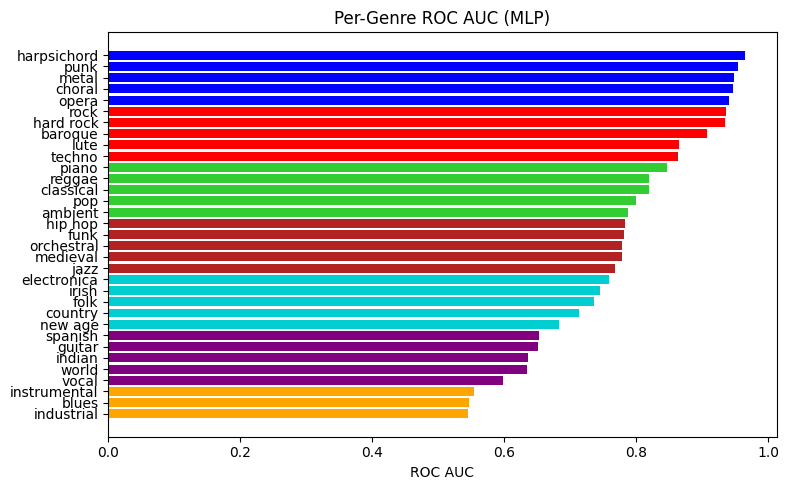

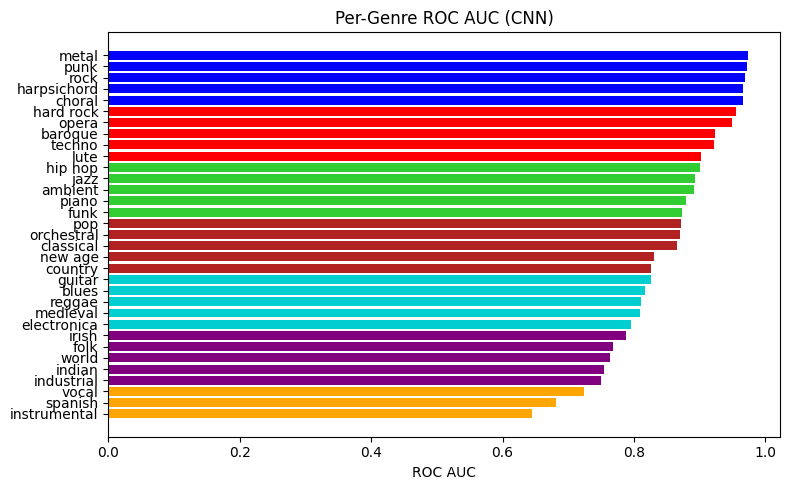

In [78]:
sorted_rocs = dict(sorted(mlp_label_rocs.items(), key=lambda x: np.nan_to_num(x[1], nan=0), reverse=True))

plt.figure(figsize=(8,5))

#generate color list. 
color = ["orange"]*3 + ["purple"]*5 + ["darkturquoise"]*5+ ["firebrick"]*5 + ["limegreen"]*5  +["red"]*5 + ["blue"]*5
plt.barh(list(sorted_rocs.keys())[::-1], list(sorted_rocs.values())[::-1], color = color)  
plt.xlabel("ROC AUC")
plt.title("Per-Genre ROC AUC (MLP)")
plt.tight_layout()
plt.show()

sorted_rocs = dict(sorted(cnn_label_rocs.items(), key=lambda x: np.nan_to_num(x[1], nan=0), reverse=True))

plt.figure(figsize=(8,5))
plt.barh(list(sorted_rocs.keys())[::-1], list(sorted_rocs.values())[::-1], color = color)
plt.xlabel("ROC AUC")
plt.title("Per-Genre ROC AUC (CNN)")
plt.tight_layout()
plt.show()

